# 🚢 Titanic Survival Prediction using Logistic Regression

This notebook uses the **Seaborn Titanic dataset** to build a Logistic Regression model.

**Steps covered:**
- Data loading
- Data cleaning (Pandas 3.0 safe)
- Feature encoding
- Model training
- Evaluation using Accuracy, Precision, Recall
- Confusion Matrix


In [16]:
# Import required libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [17]:
# Load Titanic dataset from seaborn library into a pandas DataFrame
df = sns.load_dataset('titanic')
df.head() # Display the first 5 rows of the DataFrame

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [18]:
df.info() # Check data types and non-null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [19]:
df.describe() # Get statistical summary of numerical columns

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
# Select relevant columns for the survival prediction model
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
df.head() # Display the first 5 rows of the DataFrame with selected columns

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [21]:
# Handle missing values in 'age', 'fare', and 'embarked' columns
# For 'age' and 'fare', fill missing values with their respective medians
# For 'embarked', fill missing values with the most frequent value (mode)
# This is a Pandas 3.0 safe approach
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df.isnull().sum() # Check for any remaining missing values

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0


In [22]:
# Encode categorical variables into numerical format
# 'sex' column: map 'male' to 0 and 'female' to 1
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
# 'embarked' column: use one-hot encoding (get_dummies) and drop the first category to avoid multicollinearity
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

df.head() # Display the DataFrame after encoding

,survived,pclass,sex,age,sibsp,parch,fare,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [23]:
# Separate features (X) and target variable (y)
# X will contain all columns except 'survived'
# y will contain the 'survived' column (what we want to predict)
X = df.drop('survived', axis=1)
y = df['survived']

In [24]:
# Split the dataset into training and testing sets
# 80% of data will be used for training (X_train, y_train)
# 20% of data will be used for testing (X_test, y_test)
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
# Initialize and train the Logistic Regression model
# max_iter is set to 1000 to ensure convergence
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train) # Fit the model to the training data

LogisticRegression(max_iter=1000)

In [26]:
# Make predictions on the test set using the trained model
y_pred = model.predict(X_test)

In [27]:
# Calculate and print evaluation metrics for the model's performance
accuracy = accuracy_score(y_test, y_pred) # Overall prediction accuracy
precision = precision_score(y_test, y_pred) # Proportion of positive identifications that were actually correct
recall = recall_score(y_pred, y_test) # Proportion of actual positives that were identified correctly

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")

Accuracy : 0.810
Precision: 0.786
Recall   : 0.786


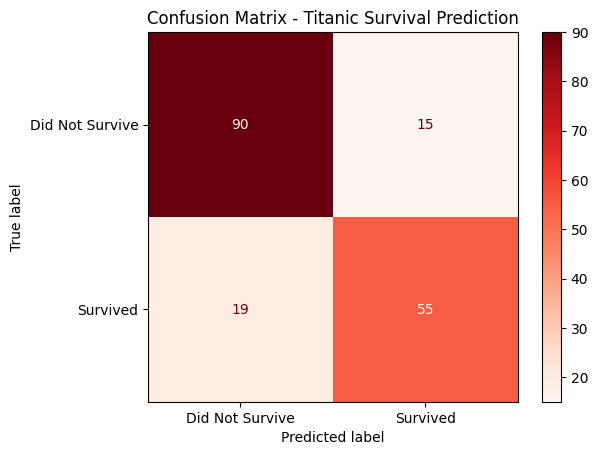

In [28]:
# Generate and display the Confusion Matrix
# The confusion matrix shows the number of correct and incorrect predictions made by the classification model
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Did Not Survive', 'Survived']
)

disp.plot(cmap='Reds') # Plot the confusion matrix with a 'Reds' colormap
plt.title("Confusion Matrix - Titanic Survival Prediction") # Set the title of the plot
plt.show() # Display the plot

### Confusion Matrix Explanation

The confusion matrix provides a detailed breakdown of the model's predictions:

*   **True Negatives (Top-Left, 90):** The model correctly predicted 'Did Not Survive' (0).
*   **False Positives (Top-Right, 15):** The model incorrectly predicted 'Survived' (1) when the actual outcome was 'Did Not Survive' (0). This is a Type I error.
*   **False Negatives (Bottom-Left, 19):** The model incorrectly predicted 'Did Not Survive' (0) when the actual outcome was 'Survived' (1). This is a Type II error.
*   **True Positives (Bottom-Right, 55):** The model correctly predicted 'Survived' (1).

In summary, out of 179 test cases, your model correctly predicted 90 non-survivors and 55 survivors. It made 15 false positive errors and 19 false negative errors. These numbers are used to calculate the accuracy, precision, and recall scores.